Task was destroyed but it is pending!
task: <Task pending name='Task-90' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Laptop\miniconda3\envs\mypythonenv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-91' coro=<Kernel.shell_main() running at C:\Users\Laptop\miniconda3\envs\mypythonenv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Laptop\miniconda3\envs\mypythonenv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Laptop\miniconda3\envs\mypythonenv\Lib\site-packages\pandas\io\parsers\base_parser.py:434: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  if isinstance(self.parse_dates, list):
Task was destroyed but it is pending!
task: <Task pending name='Task-91' coro=<Kernel.shell_main() running at C:\Users\Laptop\miniconda3\envs\mypythonenv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


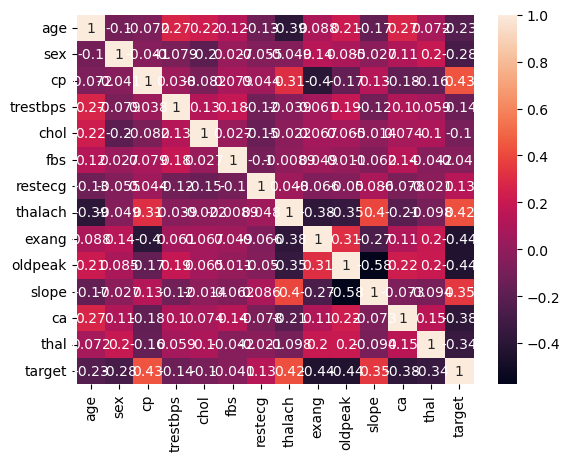

Accuracy: 0.7951219512195122
Confusion Matrix:
 [[73 29]
 [13 90]]


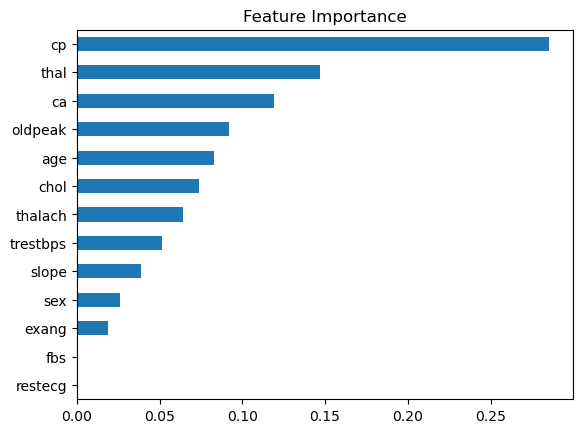

In [3]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

# Step 1: Load dataset
df = pd.read_csv("heart.csv")  # Replace with your dataset path

# Step 2: Clean dataset (handle missing values)
df.fillna(df.mean(), inplace=True)

# Step 3: Exploratory Data Analysis
sns.heatmap(df.corr(), annot=True)
plt.show()

# Step 4: Split data
X = df.drop('target', axis=1)  # Replace 'target' with your label column
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train a model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Step 6: Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Optional: Feature importance with Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()